# Machine Learning Health Data Study Project: Stroke Risk Classification

Public portfolio version of a study project. Personal data, internal course material and non-essential administrative content have been removed.

This notebook analyses a structured healthcare dataset to explore factors associated with stroke risk and to build a machine learning classification model. The project was completed as part of a study assignment in the BSc Applied Digital Life Sciences at Zurich University of Applied Sciences (ZHAW).

The analysis focuses on male patients and uses health-related variables such as age, hypertension, heart disease, average glucose level, BMI, smoking status and other patient characteristics. The main objective is to prepare the dataset, explore relevant patterns and train classification models that distinguish between stroke and non-stroke cases.

The notebook covers data preprocessing, exploratory data analysis, feature preparation, model training, evaluation and interpretation of classification results. The project demonstrates a complete machine learning workflow using Python, pandas, scikit-learn and common visualisation libraries.

The goal of this project is not to provide medical advice or develop a clinically validated diagnostic tool. Instead, it serves as an educational machine learning project that illustrates how health data can be prepared, analysed and used for supervised classification.

# Projektarbeit: Analyse des Schlaganfallrisikos

**Kurs:** Maschinelles Lernen (MaLe-AD24-HS25)  
**Autor/in:** Kenan Smaili 

### **Einführung**

Dieses Projekt untersucht, ob sich das individuelle Risiko eines Schlaganfalls anhand Gesundheits- und Lebensstilvariablen vorhersagen lässt.  
Dazu wird ein binäres Klassifikationsmodell entwickelt, das zwischen *„Schlaganfall”* und *„kein Schlaganfall”* unterscheidet.

#### **Problemstellung**
Schlaganfälle gehören weltweit zu den häufigsten Todes- und Invaliditätsursachen. Eine frühzeitige Risikoerkennung bietet die Möglichkeit, gefährdete Personen früher zu identifizieren, präventive Massnahmen zu ergreifen und damit gesundheitliche Folgen zu reduzieren.

#### **Datengrundlage**
- **Quelle:** [Kaggle – Stroke Prediction Dataset](https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset) 
- **Beobachtungen:** 5110 Personen  
- **Variablen:** Alter, BMI, Glukosewert, Raucherstatus, Hypertonie, Herzkrankheiten, Wohnsituation, Arbeitskategorie usw.

#### **Zielvariable**
- **stroke**  
  - *1* = Schlaganfall  
  - *0* = kein Schlaganfall

#### **Verwendete Features**
Die wichtigsten Merkmale umfassen:
- demographische Faktoren (Alter, Geschlecht, Wohnorttyp),
- Gesundheitsvariablen (Hypertonie, Herzkrankheiten, BMI, Glukose),
- Lebensstil (Raucherstatus, Arbeitskategorie),
- zusätzlich generierte Features (z. B. *cardio_risk_score*, *missing-flag*, *age_group*).



---
## **Setup**


Our color palette:


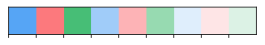

In [1]:
# Basic imports
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Modules from pandas
from pandas import CategoricalDtype
from pandas.api.types import is_numeric_dtype, is_bool_dtype

# Modules from scipy
from scipy.stats import gaussian_kde

#Modules form sklearn
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    RocCurveDisplay,
    precision_recall_curve,
    average_precision_score,
    confusion_matrix,
    make_scorer,
    precision_score,
    fbeta_score,)
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold,
    RandomizedSearchCV)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Enable vectorized graphics
%config InlineBackend.figure_formats = ["svg"]

# Setup plotting
PALETTE = [ (0.341, 0.648, 0.962, 1.0), 
            (0.990, 0.476, 0.494, 1.0), 
            (0.281, 0.749, 0.463, 1.0), 
            (0.629, 0.802, 0.978, 1.0), 
            (0.994, 0.705, 0.715, 1.0), 
            (0.595, 0.858, 0.698, 1.0), 
            (0.876, 0.934, 0.992, 1.0), 
            (0.998, 0.901, 0.905, 1.0), 
            (0.865, 0.952, 0.899, 1.0) ]

print("Our color palette:")
sns.palplot(PALETTE, size=0.5)

sns.set_style("whitegrid")
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=PALETTE)
plt.rcParams["figure.dpi"] = 300    # High-res figures (DPI)
plt.rcParams["pdf.fonttype"] = 42   # Editable text in PDF

from matplotlib.colors import LinearSegmentedColormap

cmap_palette = LinearSegmentedColormap.from_list(
    "palette_cmap",
    [PALETTE[0], PALETTE[3], PALETTE[6], PALETTE[7], PALETTE[4], PALETTE[1]]
)

---
## **Präprozessierung**

In diesem Abschnitt wird der Datensatz bereinigt, normalisiert und für die weitere Analyse vorbereitet. Dabei werden Datentypen vereinheitlicht, fehlende Werte behandelt und irrelevante Variablen entfernt.

#### **Durchgeführte Schritte**
- Vereinheitlichung der Datentypen (numerisch, kategorial, binär).
- Normalisierung aller textbasierten Kategorien (Kleinschreibung, Entfernung von Leerzeichen, Korrektur von Tippfehlern).
- Umwandlung binärer Variablen in ein konsistentes {0, 1}-Format.
- Erkennung und Markierung fehlender Werte, jedoch noch keine Imputation ausserhalb der Modell-Pipeline.
- Entfernung der Variablen id, da sie keinen prognostischen Informationsgehalt trägt.
- Erstellung einer strukturierten Übersicht mittels `quick_overview`.






In [2]:
## Präprozessierung – Daten laden und Überblick

# Datensatz laden
original_df = pd.read_csv("./data/healthcare-dataset-stroke-data.csv")
# Hilfsfunktionen für Übersichtstabelle
def _is_categorical(s: pd.Series) -> bool:
    return isinstance(s.dtype, CategoricalDtype)

def _is_ordinal(s: pd.Series) -> bool:
    return isinstance(s.dtype, CategoricalDtype) and s.dtype.ordered

def _format_numeric_summary(s: pd.Series) -> str:
    desc = s.describe()
    parts = []
    for k, v in desc.items():
        if pd.isna(v):
            parts.append(f"{k}=NA")
        elif isinstance(v, (int, float, np.floating, np.integer)):
            parts.append(f"{k}={float(v):.4g}")
        else:
            parts.append(f"{k}={v}")
    return ", ".join(parts)

def _format_counts_sorted(s: pd.Series) -> str:
    if not isinstance(s.dtype, pd.CategoricalDtype):
        s = s.astype("category")
    vc = s.value_counts(dropna=False).sort_index()
    return " | ".join(f"{str(k)}: {int(v)}" for k, v in vc.items())

def quick_overview(df: pd.DataFrame, binary_cols) -> pd.DataFrame:
    rows = []
    for c in df.columns:
        s = df[c]
        total = len(s)
        miss = int(s.isna().sum())

        if c in binary_cols:
            details = _format_counts_sorted(s.astype("category"))
        elif is_numeric_dtype(s):
            details = _format_numeric_summary(s)
        elif is_bool_dtype(s) or _is_ordinal(s) or _is_categorical(s):
            details = _format_counts_sorted(s)
        else:
            details = _format_counts_sorted(s.astype("string"))

        rows.append({
            "Feature": c,
            "dtype": str(s.dtype),
            "n": total,
            "missing": f"{miss}/{total}",
            "pct_missing": round(miss / total * 100, 2),
            "Details": details,
        })

    return (
        pd.DataFrame(rows)
        .sort_values("Feature")
        .reset_index(drop=True)
    )

with pd.option_context("display.max_colwidth", None):
    display(quick_overview(original_df, binary_cols=["hypertension", "heart_disease", "stroke"]))

,Feature,dtype,n,missing,pct_missing,Details
0,Residence_type,object,5110,0/5110,0.00,Rural: 2514 | Urban: 2596
1,age,float64,5110,0/5110,0.00,"count=5110, mean=43.23, std=22.61, min=0.08, 25%=25, 50%=45, 75%=61, max=82"
2,avg_glucose_level,float64,5110,0/5110,0.00,"count=5110, mean=106.1, std=45.28, min=55.12, 25%=77.25, 50%=91.88, 75%=114.1, max=271.7"
3,bmi,float64,5110,201/5110,3.93,"count=4909, mean=28.89, std=7.854, min=10.3, 25%=23.5, 50%=28.1, 75%=33.1, max=97.6"
4,ever_married,object,5110,0/5110,0.00,No: 1757 | Yes: 3353
5,gender,object,5110,0/5110,0.00,Female: 2994 | Male: 2115 | Other: 1
6,heart_disease,int64,5110,0/5110,0.00,0: 4834 | 1: 276
7,hypertension,int64,5110,0/5110,0.00,0: 4612 | 1: 498
8,id,int64,5110,0/5110,0.00,"count=5110, mean=3.652e+04, std=2.116e+04, min=67, 25%=1.774e+04, 50%=3.693e+04, 75%=5.468e+04, max=7.294e+04"
9,smoking_status,object,5110,0/5110,0.00,Unknown: 1544 | formerly smoked: 885 | never smoked: 1892 | smokes: 789


In [3]:
## Präprozessierung – Normalisierung / Bereinigung

df_normalized = original_df.copy() 
# Im Sinne von "good practice" verwenden wir eine Kopie des originalen Datensatzes um den ursprünglichen Datensatz unberührt zu lassen

# Numerische Spalten als float
df_normalized["age"] = pd.to_numeric(df_normalized["age"], errors="coerce")
df_normalized["avg_glucose_level"] = pd.to_numeric(
    df_normalized["avg_glucose_level"], errors="coerce"
)
df_normalized["bmi"] = pd.to_numeric(df_normalized["bmi"], errors="coerce")

# Binäre Variablen als float 0/1
for col_bin in ["hypertension", "heart_disease", "stroke"]:
    df_normalized[col_bin] = pd.to_numeric(
        df_normalized[col_bin], errors="coerce"
    ).astype(float)

# ever_married -> 0/1 (float)
df_normalized["ever_married"] = (
    df_normalized["ever_married"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map({"no": 0.0, "yes": 1.0})
)

# Strings säubern (lowercase etc.)
df_normalized["gender"] = (
    df_normalized["gender"].astype(str).str.strip().str.lower()
)

df_normalized["work_type"] = (
    df_normalized["work_type"]
    .astype(str)
    .str.strip()
    .str.lower()
    .str.replace(r"[-\s]+", "_", regex=True)
    .str.replace("govt_jov", "govt_job")
)

df_normalized = df_normalized.rename(columns={"Residence_type": "residence_type"}) # umbenennen des Spaltennamens
df_normalized["residence_type"] = (
    df_normalized["residence_type"].astype(str).str.strip().str.lower()
)

df_normalized["smoking_status"] = (
    df_normalized["smoking_status"]
    .astype(str)
    .str.strip()
    .str.lower()
    .str.replace(r"\s+", " ", regex=True)
)
df_normalized.loc[
    df_normalized["smoking_status"] == "unknown", "smoking_status"
] = np.nan

# id als pure ID entfernen
df_normalized = df_normalized.drop(columns=["id"])

with pd.option_context("display.max_colwidth", None):
    display(
        quick_overview(
            df_normalized,
            binary_cols=["hypertension", "heart_disease", "ever_married", "stroke"],
        )
    )

,Feature,dtype,n,missing,pct_missing,Details
0,age,float64,5110,0/5110,0.00,"count=5110, mean=43.23, std=22.61, min=0.08, 25%=25, 50%=45, 75%=61, max=82"
1,avg_glucose_level,float64,5110,0/5110,0.00,"count=5110, mean=106.1, std=45.28, min=55.12, 25%=77.25, 50%=91.88, 75%=114.1, max=271.7"
2,bmi,float64,5110,201/5110,3.93,"count=4909, mean=28.89, std=7.854, min=10.3, 25%=23.5, 50%=28.1, 75%=33.1, max=97.6"
3,ever_married,float64,5110,0/5110,0.00,0.0: 1757 | 1.0: 3353
4,gender,object,5110,0/5110,0.00,female: 2994 | male: 2115 | other: 1
5,heart_disease,float64,5110,0/5110,0.00,0.0: 4834 | 1.0: 276
6,hypertension,float64,5110,0/5110,0.00,0.0: 4612 | 1.0: 498
7,residence_type,object,5110,0/5110,0.00,rural: 2514 | urban: 2596
8,smoking_status,object,5110,1544/5110,30.22,formerly smoked: 885 | never smoked: 1892 | smokes: 789 | <NA>: 1544
9,stroke,float64,5110,0/5110,0.00,0.0: 4861 | 1.0: 249


#### **Feststellungen**
- Im Datensatz traten fehlende Werte in den Variablen `bmi` und `smoking_status` auf. Diese konnten korrekt identifiziert und für die weitere Verarbeitung markiert werden.

- Die Datenqualität ist insgesamt gut. Allerdings enthielten einige Kategorien – etwa "Unknown" im Raucherstatus – Werte, die semantisch unklar waren. Diese wurden konsequent in echte fehlende Werte (NA) überführt, damit die Modelle sauber damit umgehen können.

- Die Datentypen wurden vereinheitlicht (v. a. float64 für numerische und object für kategoriale Variablen), damit alle Schritte in der späteren ColumnTransformer-Pipeline stabil funktionieren. Wir haben bewusst darauf verzichtet, z. B. age in Integer oder residence_type in eigene String-Typen zu überführen, weil die Scikit-Learn-Pipeline am zuverlässigsten mit den standardisierten NumPy/Pandas-Typen arbeitet.

- Alle binären Variablen liegen nun vollständig im numerischen Format vor (0/1 statt Ja/Nein). Damit erfüllen sie die Anforderungen der Encoder und Klassifikationsmodelle.

- Durch die Datenbereinigung ist der Datensatz nun konsistent, vollständig definiert und kompatibel mit allen nachfolgenden Schritten der Modellpipeline.

---
## **Explorative Datenanalyse**

Die explorative Analyse dient dem ersten Verständnis der Datenstruktur und der Identifikation wichtiger Muster, Ausreisser und potenziell relevanter Prädiktoren für das Schlaganfallrisiko.  

### **Untersuchte Aspekte**
1. Verteilungsanalysen numerischer Variablen (*age*, *bmi*, *avg_glucose_level*). 
2. Durch Boxplots und Violinplots die Verteilungen gegenüber die Zielvariable darstellen.
3. Häufigkeitsdarstellungen kategorialer Merkmale (*gender*, *Residence_type*, *work_type*, *smoking_status*).  
4. Korrelationsmatrix zentraler numerischer Variablen.

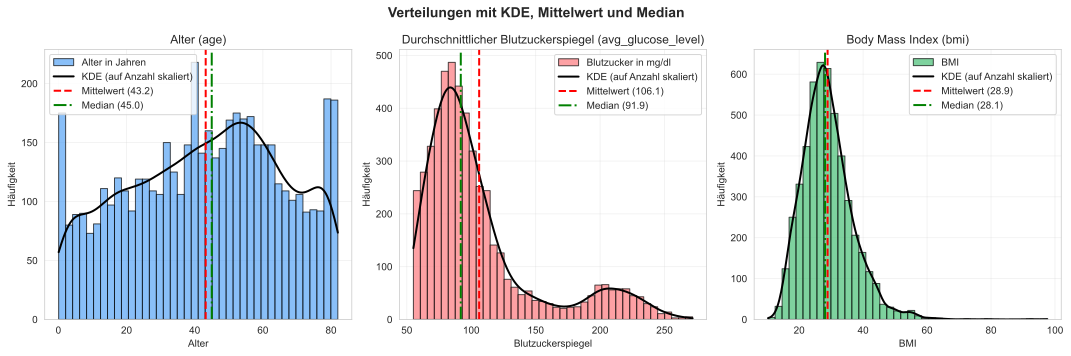

In [4]:
## Explorative Datenanalyse : Balkendiagramme

# Visualisierung numerischer Variablen
col_age      = PALETTE[0]   # blau
col_glucose  = PALETTE[1]   # rot/koralle
col_bmi      = PALETTE[2]   # grün

mean_color   = "red"
median_color = "green"

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))
bins = 40

# 1) Alter (age)
data_age = df_normalized["age"].dropna()
ax1.hist(
    data_age, bins=bins,
    color=col_age, edgecolor="black", alpha=0.7,
    label="Alter in Jahren"
)

# 1.1) Glättungskurven (KDE) für Alter
kde1 = gaussian_kde(data_age)
x1 = np.linspace(data_age.min(), data_age.max(), 500)
ax1.plot(
    x1,
    kde1(x1) * len(data_age) * (data_age.max() - data_age.min()) / bins,
    color="black", linewidth=2, label="KDE (auf Anzahl skaliert)"
)

ax1.axvline(data_age.mean(), color=mean_color, linestyle="--", linewidth=2,
            label=f"Mittelwert ({data_age.mean():.1f})")
ax1.axvline(data_age.median(), color=median_color, linestyle="-.", linewidth=2,
            label=f"Median ({data_age.median():.1f})")

ax1.set_title("Alter (age)")
ax1.set_xlabel("Alter")
ax1.set_ylabel("Häufigkeit")
ax1.legend()
ax1.grid(alpha=0.3)

# 2) Glukose (avg_glucose_level)
data_glu = df_normalized["avg_glucose_level"].dropna()
ax2.hist(
    data_glu, bins=bins,
    color=col_glucose, edgecolor="black", alpha=0.7,
    label="Blutzucker in mg/dl"
)

# 2.1) Glättungskurven (KDE) für Glukose
kde2 = gaussian_kde(data_glu)
x2 = np.linspace(data_glu.min(), data_glu.max(), 300)
ax2.plot(
    x2,
    kde2(x2) * len(data_glu) * (data_glu.max() - data_glu.min()) / bins,
    color="black", linewidth=2, label="KDE (auf Anzahl skaliert)"
)

ax2.axvline(data_glu.mean(), color=mean_color, linestyle="--", linewidth=2,
            label=f"Mittelwert ({data_glu.mean():.1f})")
ax2.axvline(data_glu.median(), color=median_color, linestyle="-.", linewidth=2,
            label=f"Median ({data_glu.median():.1f})")

ax2.set_title("Durchschnittlicher Blutzuckerspiegel (avg_glucose_level)")
ax2.set_xlabel("Blutzuckerspiegel")
ax2.set_ylabel("Häufigkeit")
ax2.legend()
ax2.grid(alpha=0.3)

# 3) BMI
data_bmi = df_normalized["bmi"].dropna()
ax3.hist(
    data_bmi, bins=bins,
    color=col_bmi, edgecolor="black", alpha=0.7,
    label="BMI"
)

# 3.1) Glättungskurven (KDE) für BMI
kde3 = gaussian_kde(data_bmi)
x3 = np.linspace(data_bmi.min(), data_bmi.max(), 300)
ax3.plot(
    x3,
    kde3(x3) * len(data_bmi) * (data_bmi.max() - data_bmi.min()) / bins,
    color="black", linewidth=2, label="KDE (auf Anzahl skaliert)"
)

ax3.axvline(data_bmi.mean(), color=mean_color, linestyle="--", linewidth=2,
            label=f"Mittelwert ({data_bmi.mean():.1f})")
ax3.axvline(data_bmi.median(), color=median_color, linestyle="-.", linewidth=2,
            label=f"Median ({data_bmi.median():.1f})")

ax3.set_title("Body Mass Index (bmi)")
ax3.set_xlabel("BMI")
ax3.set_ylabel("Häufigkeit")
ax3.legend()
ax3.grid(alpha=0.3)

fig.suptitle("Verteilungen mit KDE, Mittelwert und Median", fontsize=14, weight="bold")
plt.tight_layout()
plt.show()

In [5]:
## Explorative Datenanalyse : Box-Plots und Violin-Plots

def box_violin_by_target(df, target_col, feature_cols):
    n_features = len(feature_cols)
    fig, axes = plt.subplots(n_features, 2, figsize=(12, 5 * n_features), sharey=False)
    if n_features == 1:
        axes = [axes]

    plot_df = df.copy()
    plot_df[target_col] = plot_df[target_col].astype(str)

    levels = plot_df[target_col].dropna().unique()
    try:
        order = [str(x) for x in sorted(levels, key=lambda v: float(v))]
    except Exception:
        order = sorted([str(x) for x in levels])

    class_palette = {lvl: PALETTE[i % len(PALETTE)] for i, lvl in enumerate(order)}

    neutral = "black"
    median_col = "black"

    for i, feat in enumerate(feature_cols):
        ax_box, ax_violin = axes[i]

        # Box-Plots
        sns.boxplot(
            data=plot_df,
            x=target_col,
            y=feat,
            order=order,
            hue=target_col,            
            hue_order=order,
            dodge=False,
            legend=False,              
            ax=ax_box,
            palette=class_palette,
            showcaps=True,
            boxprops={"alpha": 0.6},
            medianprops={"color": median_col},
            whiskerprops={"color": neutral},
            capprops={"color": neutral},
            flierprops={"markeredgecolor": neutral, "alpha": 0.4},
        )
        ax_box.set_title(f"{feat} Verteilung nach {target_col} – Boxplot", fontsize=12, weight="bold")
        ax_box.set_xlabel(target_col)
        ax_box.set_ylabel(feat)

        # Violin-plots
        sns.violinplot(
            data=plot_df,
            x=target_col,
            y=feat,
            order=order,
            hue=target_col,            
            hue_order=order,
            dodge=False,
            legend=False,
            inner=None,
            ax=ax_violin,
            palette=class_palette,
            saturation=0.85,
        )
        ax_violin.set_title(f"{feat} Verteilung nach {target_col} – Violinplot", fontsize=12, weight="bold")
        ax_violin.set_xlabel(target_col)
        ax_violin.set_ylabel("")

        if target_col == "stroke":
            labels = ["no" if float(o) == 0 else "yes" for o in order]
            for ax in (ax_box, ax_violin):
                ax.set_xticks(range(len(order)))
                ax.set_xticklabels(labels)
                ax.set_xlabel("stroke history")

    plt.tight_layout()
    plt.show()

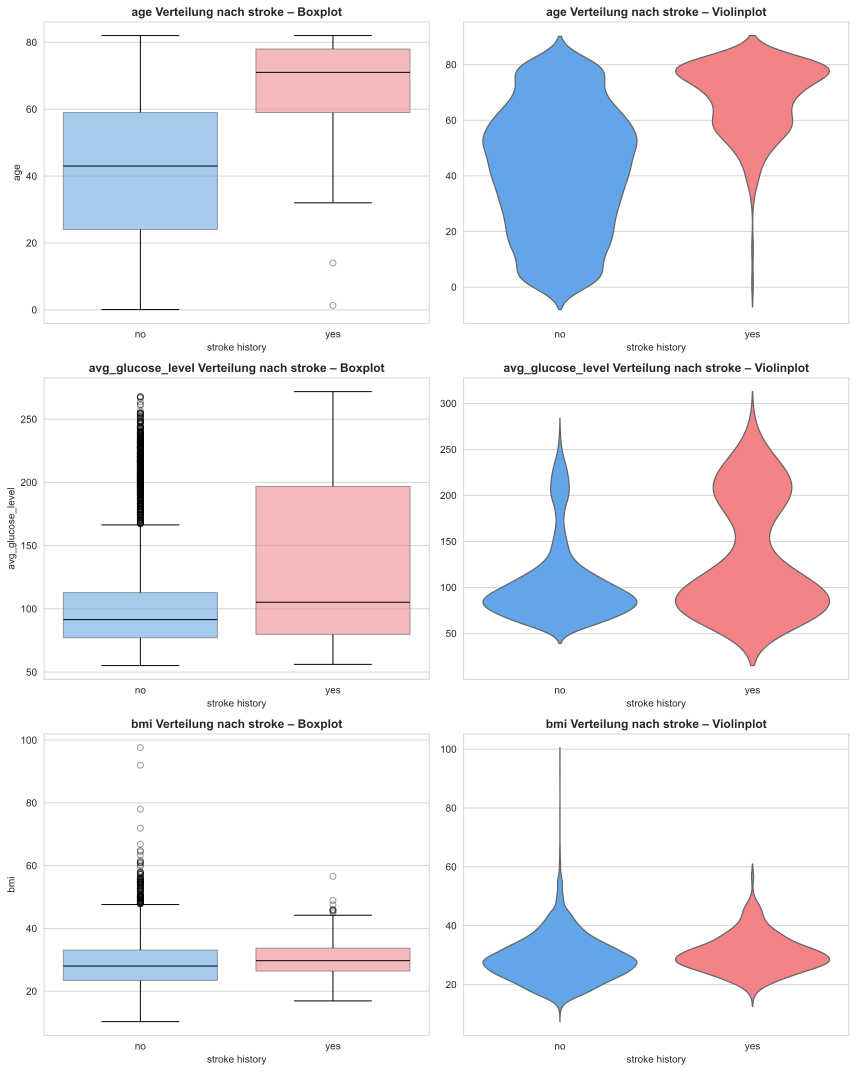

In [6]:
numeric_features = ["age", "avg_glucose_level", "bmi"]
box_violin_by_target(df_normalized, target_col="stroke", feature_cols=numeric_features)

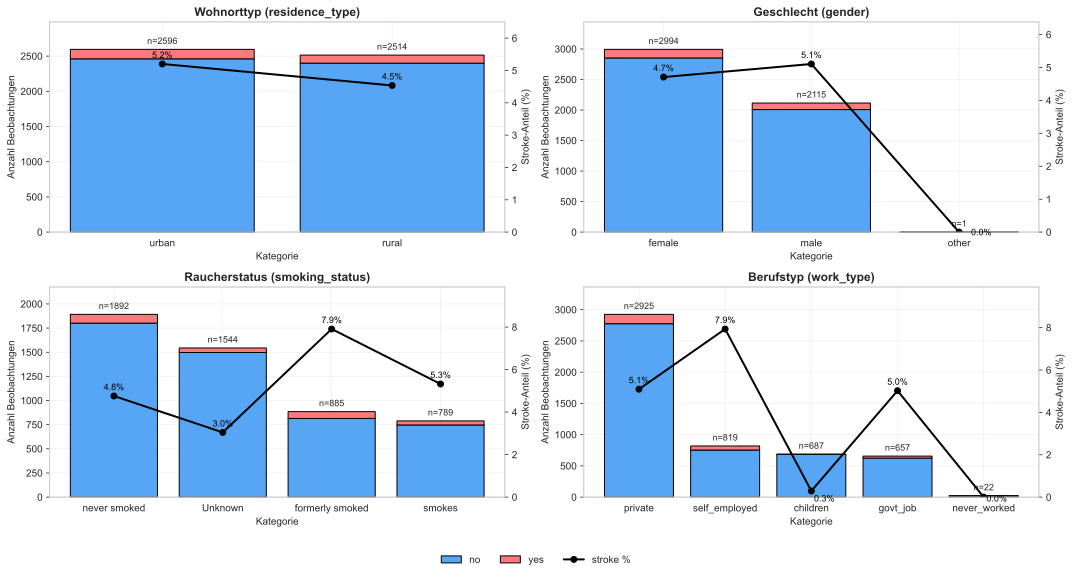

In [7]:
## Explorative Datenanalyse : Balkendiagramme

stroke_palette = {"no": PALETTE[0], "yes": PALETTE[1]}
line_color = "black"

def plot_counts_and_stroke_rate(df, col, ax, title=None, sort_by="n"):
    
    tmp = df[[col, "stroke"]].copy()
    tmp["stroke_label"] = tmp["stroke"].map({0.0:"no", 1.0:"yes", 0:"no", 1:"yes"})
    tmp[col] = tmp[col].astype(str)

    ct = pd.crosstab(tmp[col], tmp["stroke_label"])
    for k in ["no", "yes"]:
        if k not in ct.columns:
            ct[k] = 0
    ct = ct[["no", "yes"]]

    totals = ct.sum(axis=1)
    rate = (ct["yes"] / totals).fillna(0)  

    if sort_by == "n":
        idx = totals.sort_values(ascending=False).index
    elif sort_by == "rate":
        idx = rate.sort_values(ascending=False).index
    else:
        idx = sorted(ct.index)
    ct, totals, rate = ct.loc[idx], totals.loc[idx], rate.loc[idx]

    x = np.arange(len(ct.index))

    # Balken
    ax.bar(x, ct["no"],  color=stroke_palette["no"],  edgecolor="black", label="no")
    ax.bar(x, ct["yes"], bottom=ct["no"], color=stroke_palette["yes"], edgecolor="black", label="yes")
    ax.set_ylabel("Anzahl Beobachtungen")
    ax.set_xlabel("Kategorie")
    ax.set_title(title or f"{col} – Counts + Stroke-%", fontsize=12, weight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(ct.index, rotation=0)
    ax.grid(alpha=0.3)
 
    ymax = totals.max()
    ax.set_ylim(0, ymax * 1.15)

    for i, cat in enumerate(ct.index):
        ax.text(
            i,
            totals.loc[cat] + ymax * 0.02,
            f"n={int(totals.loc[cat])}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

    # Linien für stroke
    ax2 = ax.twinx()
    ax2.plot(x, rate.values * 100, marker="o", linewidth=2, color=line_color, label="stroke %")
    ax2.set_ylabel("Stroke-Anteil (%)")
    ax2.set_ylim(0, max(5, (rate.max() * 100) * 1.25))
    ax2.grid(False)

    # Prozent-Beschriftungen: kleine Werte unterhalb & leicht versetzt
    top2 = ax2.get_ylim()[1]

    for i, val in enumerate(rate.values * 100):
        label = f"{val:.1f}%"

        if val < 0.5:
            y_pos = max(val - top2 * 0.05, 0.1)
            va = "top"
            x_pos = i + 0.15
        else:
            y_pos = val + top2 * 0.02
            va = "bottom"
            x_pos = i

        ax2.text(
            x_pos,
            y_pos,
            label,
            ha="center",
            va=va,
            fontsize=9,
            color=line_color,
        )

    return ax, ax2

# 2x2 Layout 
fig, axes = plt.subplots(2, 2, figsize=(15, 8))
axes = axes.ravel()

handles_for_legend = None

for ax, (df_, col_, title_) in zip(
    axes,
    [
        (df_normalized, "residence_type", "Wohnorttyp (residence_type)"),
        (df_normalized, "gender", "Geschlecht (gender)"),
        (original_df,   "smoking_status", "Raucherstatus (smoking_status)"),
        (df_normalized, "work_type", "Berufstyp (work_type)"),
    ]
):
    ax_main, ax_rate = plot_counts_and_stroke_rate(df_, col_, ax, title_, sort_by="n")

    if handles_for_legend is None:
        h1, l1 = ax_main.get_legend_handles_labels()     # no/yes
        h2, l2 = ax_rate.get_legend_handles_labels()     # stroke %
        handles_for_legend = (h1 + h2, l1 + l2)

# Legende 
fig.legend(*handles_for_legend, loc="lower center", ncol=3, frameon=False)
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()

***Hinweis***  
Für die Darstellung von `smoking_status` wurde absichtliche der ursprüngliche Datensatz (original_df) verwendet, um die Kategorie *Unknown* sichtbar zu machen.

In [8]:
# Ausgewählte Variablen für die weitere Analyse:
selected_num_1 = ["age", "hypertension","heart_disease","avg_glucose_level","bmi","stroke"] # OHNE "id" da kein Informationsgehalt
selected_num_2 = ["age", "avg_glucose_level", "bmi", "stroke"] # nur Variablen mit mehreren Kategorien und Zielvariable
selected_num_3 = ["age", "avg_glucose_level", "bmi"] # nur Variablen mit mehreren Kategorien OHNE Zielvariable "stroke"
selected_num_4 = ["hypertension","heart_disease","stroke"] # nur Variablen mit binären Kategorien und Zielvariable
selected_num_5 = ["age", "hypertension","heart_disease","avg_glucose_level","bmi"] # OHNE Zielvariable "stroke"

In [9]:
## Explorative Datenanalyse : Korrelationsmatrix/ Heatmap

def plot_correlation_heatmap(df):
    corr = df.corr()
    plt.figure(figsize=(10, 8))

    # Heatmap
    sns.heatmap(
        corr,
        annot=True,
        fmt=".2f",
        cmap=cmap_palette,
        linewidths=0.5,
        linecolor="gray",
        square=True,
        cbar_kws={"shrink": 0.8},
        annot_kws={"size": 9}
    )

    plt.title("Correlation Matrix of Numerical Features", fontsize=14)
    plt.tight_layout()
    plt.show()

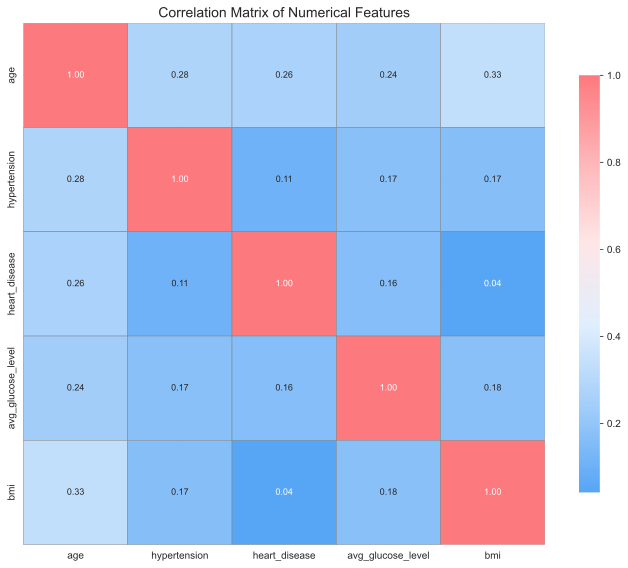

In [10]:
plot_correlation_heatmap(df_normalized[selected_num_5])

In [11]:
# Übersicht Korrelation für Features
corr = df_normalized[selected_num_5].corr()
display(corr.round(2))

,age,hypertension,heart_disease,avg_glucose_level,bmi
age,1.00,0.28,0.26,0.24,0.33
hypertension,0.28,1.00,0.11,0.17,0.17
heart_disease,0.26,0.11,1.00,0.16,0.04
avg_glucose_level,0.24,0.17,0.16,1.00,0.18
bmi,0.33,0.17,0.04,0.18,1.00


### **Feststellungen**
- Die Zielvariable `stroke` ist stark unausgewogen (weniger als 5 % positive Fälle). Dies beeinflusst die Modellierung erheblich und  
erfordert den Einsatz spezieller Methoden im Training (z. B. class_weight).
- `age` zeigt eine klare Verschiebung: Personen, die einen Schlaganfall erleiden, sind im Schnitt deutlich älter.
- `avg_glucose_level` weist eine breite Streuung auf und zeigt moderate Korrelationen mit der Zielvariable.  
Die Verteilung ist rechtsschief, was den grösseren Unterschied zwischen Median und Mittelwert erklärt.
- `bmi` ist weniger stark mit dem Schlaganfallrisiko assoziiert als erwartet, zeigt aber leichte Tendenzen.
- Die kategorischen Variablen sind unterschiedlich verteilt, liefern jedoch ohne weitere Modellierung noch keine direkte Aussagekraft.
- Die Korrelationsmatrix unterstreicht die Bedeutung von `age` und `avg_gllucose_level` als potenzielle Kernmerkmale.

---
## **Feature Engineering und Dimensionalitätsreduktion**

In diesem Schritt werden zusätzliche Merkmale erzeugt, die die Modelle unterstützen sollen, relevante Muster besser zu erkennen.  
Alle erzeugten Features sind regelbasiert und können daher gefahrlos vor dem Train/Test-Split erstellt werden.

### **Feature Eingineering: Erzeugte Features**
1. **missingness-flags** für BMI und Raucherstatus, da deren Fehlen selbst ein gesundheitliches Signal darstellen kann.
2. **cardio_risk_score**: ein kombinierter Parameter aus Hypertonie und Herzkrankheiten, der kardiovaskuläre Belastungen in einem Feature bündelt.
3. **age_group**: eine kategoriale Einteilung des Alters, die nicht-lineare Zusammenhänge mit dem Schlaganfallrisiko besser abbildet.

In [12]:
## Feature Engineering 

df_preSplit = df_normalized.copy()

# 1.1) Missingness-Flags (0/1, normaler int64)
df_preSplit["bmi_missing_flag"] = df_preSplit["bmi"].isna().astype(int)
df_preSplit["smoking_missing_flag"] = df_preSplit["smoking_status"].isna().astype(int)

# 1.2) Kombinierter kardiovaskulärer Score
df_preSplit["cardio_risk_score"] = (
    df_preSplit["hypertension"].fillna(0)
    + df_preSplit["heart_disease"].fillna(0)
)

# 1.3) Altersgruppen (als object, Missing = np.nan falls age fehlte)
df_preSplit["age_group"] = pd.cut(
    df_preSplit["age"],
    bins=[0, 40, 55, 70, 120],
    labels=["<40", "40-55", "55-70", "70+"]
).astype(object)

with pd.option_context("display.max_colwidth", None):
    display(
        quick_overview(
            df_preSplit,
            binary_cols=["hypertension",
                         "heart_disease",
                         "ever_married",
                         "bmi_missing_flag",
                         "smoking_missing_flag",
                         "stroke"],
        )
    )

,Feature,dtype,n,missing,pct_missing,Details
0,age,float64,5110,0/5110,0.00,"count=5110, mean=43.23, std=22.61, min=0.08, 25%=25, 50%=45, 75%=61, max=82"
1,age_group,object,5110,0/5110,0.00,40-55: 1170 | 55-70: 986 | 70+: 710 | <40: 2244
2,avg_glucose_level,float64,5110,0/5110,0.00,"count=5110, mean=106.1, std=45.28, min=55.12, 25%=77.25, 50%=91.88, 75%=114.1, max=271.7"
3,bmi,float64,5110,201/5110,3.93,"count=4909, mean=28.89, std=7.854, min=10.3, 25%=23.5, 50%=28.1, 75%=33.1, max=97.6"
4,bmi_missing_flag,int64,5110,0/5110,0.00,0: 4909 | 1: 201
5,cardio_risk_score,float64,5110,0/5110,0.00,"count=5110, mean=0.1515, std=0.3919, min=0, 25%=0, 50%=0, 75%=0, max=2"
6,ever_married,float64,5110,0/5110,0.00,0.0: 1757 | 1.0: 3353
7,gender,object,5110,0/5110,0.00,female: 2994 | male: 2115 | other: 1
8,heart_disease,float64,5110,0/5110,0.00,0.0: 4834 | 1.0: 276
9,hypertension,float64,5110,0/5110,0.00,0.0: 4612 | 1.0: 498


**Hinweis**  
In `gender` tritt die Kategorie "other" nur einmal auf. Um CV-Warnungen (unknown categories) zu vermeiden und weil daraus kein stabiler Lerneffekt entstehen kann,  
entfernen wir diese einzelne Zeile (Filter nur nach Feature, nicht nach Target).

In [13]:
df_preSplit = df_preSplit[df_preSplit["gender"].isin(["male", "female"])].copy()

In [14]:
## Data Splitting (Train/Validation/Test)

# Features (X) und Zielvariable (y)
X = df_preSplit.drop(columns=["stroke"])
y = df_preSplit["stroke"]

# 1) Train+Val vs. Test (80% / 20%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 2) Train vs. Validation aus X_temp, y_temp
X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25,      # 25% von den 80% = 20% absolut
    random_state=42,
    stratify=y_temp
)

X_train.shape, X_val.shape, X_test.shape

((3065, 14), (1022, 14), (1022, 14))

**Hinweis**  
Es wird zweimal gesplittet um am Schluss Train, Test und Validation Sets zu haben mit den Verteilungen 60%, 20%, 20%.  
Mit dem Argument **stratify = y** wird  sichergestellt , dass alle 3 Datensätze (train, test und val) dieselbe Klassenverteilung in Bezug auf unsere Zielvariable haben.

In [15]:
## Preprocessor

numeric_features = [
    "age",
    "avg_glucose_level",
    "bmi",
    "cardio_risk_score", # ist 0/1/2 ordinal "zählend" darum numeric_feature
]

categorical_features = [
    "age_group",
    "bmi_missing_flag",
    "ever_married",
    "gender",
    "heart_disease",
    "hypertension",
    "residence_type",
    "smoking_missing_flag",
    "smoking_status",
    "work_type",  
]

# Numerischer Teil: Median-Imputation + Scaling
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

# Kategorialer Teil: Most-frequent-Imputation + One-Hot-Encoding
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore",drop="if_binary", sparse_output=False)), 
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

**Hinweise**
- Fehlende Werte in kategorialen Variablen werden mit der **häufigsten Kategorie** ersetzt (`SimpleImputer(strategy="most_frequent")`).  
  Dadurch bleibt der Datensatz vollständig und alle Kategorien können zuverlässig encodiert werden.

- Die Umwandlung in numerische Variablen erfolgt über **One-Hot-Encoding**, mit folgenden wichtigen Einstellungen:

  - **`handle_unknown="ignore"`**  
    Verhindert Fehler, wenn im Testset Kategorien erscheinen, die im Training nicht vorkamen.

  - **`drop="if_binary"`**  
    Bei binären Variablen wird nur **eine** Spalte erzeugt.  
    Dies vermeidet redundante Informationen und verhindert perfekte Multikollinearität.

  - **`sparse_output=False`**  
    Der Encoder gibt ein dichtes Array zurück.  
    Dies verbessert die Kompatibilität mit Visualisierungen wie **PCA** sowie mit Analyse-Tools im Notebook.


### **Dimensionalitätsreduktion**

**PCA (Principal Component Analysis)**

In [16]:
## PCA (Principal Component Analyisis)

pca = PCA(n_components=2, random_state=42) # PCA: 2 Komponenten

pca_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("pca", pca),
])

X_train_pca = pca_pipeline.fit_transform(X_train)

print("Erklärte Varianz pro Komponente:", np.round(pca.explained_variance_ratio_, 3))
print("Kumulative erklärte Varianz:", float(pca.explained_variance_ratio_.sum().round(3)))

X_train_pca_df = pd.DataFrame(X_train_pca, columns=["PC1", "PC2"])
X_train_pca_df["stroke"] = y_train.to_numpy()

# Legend-Labels (nur für Plot: 0.0 = no, 1.0 = yes)
X_train_pca_df["stroke_label"] = (
    X_train_pca_df["stroke"]
      .map({0.0: "no", 1.0: "yes", 0: "no", 1: "yes"})
      .astype("category")
)
X_train_pca_df["stroke_label"] = X_train_pca_df["stroke_label"].cat.set_categories(["no", "yes"])

Erklärte Varianz pro Komponente: [0.308 0.141]
Kumulative erklärte Varianz: 0.449


***LDA (Linear Discriminatn Analysis)***

In [17]:
## LDA (Linear Discriminant Analysis)

lda = LinearDiscriminantAnalysis(n_components=1) # LDA kann bei 2 Klassen maximal 1 Komponente liefern (n_components=1)

lda_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),   # derselbe Preprocessor wie bei PCA & Modellen
    ("lda", lda),
])

# Fit auf Train, LDA nutzt dabei y_train
X_train_lda = lda_pipeline.fit_transform(X_train, y_train)

# Für 2 Klassen gibt es nur eine LD-Achse (1D)
X_train_lda_df = pd.DataFrame(X_train_lda, columns=["LD1"])
X_train_lda_df["stroke"] = y_train.to_numpy()
X_train_lda_df["stroke_label"] = (
    X_train_lda_df["stroke"]
      .map({0.0: "no", 1.0: "yes", 0: "no", 1: "yes"})
      .astype("category")
)
X_train_lda_df["stroke_label"] = X_train_lda_df["stroke_label"].cat.set_categories(["no", "yes"])

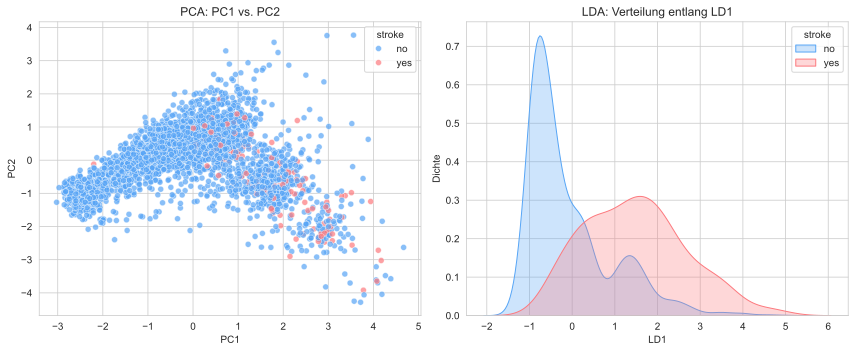

In [18]:
## PCA und LDA Visualisierung

fig, (ax_pca, ax_lda) = plt.subplots(1, 2, figsize=(12, 5))

# PCA-Scatter (links)
sns.scatterplot(
    data=X_train_pca_df,
    x="PC1",
    y="PC2",
    hue="stroke_label",
    hue_order=["no", "yes"],
    palette=[PALETTE[0], PALETTE[1]],
    alpha=0.7,
    ax=ax_pca,
)
ax_pca.set_title("PCA: PC1 vs. PC2")
ax_pca.set_xlabel("PC1")
ax_pca.set_ylabel("PC2")
ax_pca.legend(title="stroke")

# LDA-Verteilungen (rechts)
for lbl, col in zip(["no", "yes"], [PALETTE[0], PALETTE[1]]):
    sns.kdeplot(
        data=X_train_lda_df[X_train_lda_df["stroke_label"] == lbl],
        x="LD1",
        fill=True,
        alpha=0.3,
        label=lbl,
        ax=ax_lda,
        color=col,
    )

ax_lda.set_title("LDA: Verteilung entlang LD1")
ax_lda.set_xlabel("LD1")
ax_lda.set_ylabel("Dichte")
ax_lda.legend(title="stroke")

plt.tight_layout()
plt.show()


### **Feststellungen**
- Die erzeugten Features sind inhaltlich sinnvoll und erhöhen die Modellstabilität, da sie medizinische Abhängigkeiten ausdrücken.
- Die **PCA-Projektion** (PC1 vs. PC2) erklärt rund 45 % der Gesamtvarianz und zeigt zwar gewisse Cluster in den Daten, aber auch eine deutliche Überlappung der Klassen.  
  Eine perfekte Trennung im linearen Unterraum ist nicht möglich, weshalb eine Redution der Dimensionalität für die Modellierung nicht erforderlich ist; die PCA wir lediglich zur Exploration verwendet.
- Die **LDA** komprimiert die Daten auf eine diskriminative Achse (LD1), auf der sich die Verteilungen von `stroke`= *yes* und `stroke` = "no" zwar verschieben, aber weiterhin stark überlappen.  
  Dieser Befund bestätigt erneut, dass das Schlaganfallrisiko nicht durch eine einfache lineare Entscheidungsgrenze getrennt werden kann.

---
## **Modellieren, Trainieren und Validieren**

Im Modellierungsteil wurden zwei Klassifikationsmodelle implementiert:

1. **Logistische Regression**  
2. **Random Forest**

Beide Modelle sind in vollständige Pipelines eingebettet, welche sicherstellen, dass
- fehlende Werte korrekt imputiert werden,
- numerische Variablen skaliert werden,
- kategoriale Variablen one-hot-encodiert werden,
- kein Data Leakage entsteht.


### **Cross-Validation (CV)**

Zur zuverlässigen Bewertung wurde eine stratifizierte 5-fold Cross-Validation eingesetzt.  
Dies stellt sicher:

- alle Folds besitzen die gleiche Klassenverteilung wie die Gesamtdaten,
- Modelle werden fair und stabil bewertet,
- Overfitting auf ein einzelnes Trainings-/Validierungsset wird vermieden.


### **Scoring-Metriken**

Da die Zielvariable (Schlaganfall) stark unausgeglichen ist (~5 % positiv), eignen sich klassische Metriken wie Accuracy kaum.

Verwendete Metriken:

- **Recall**: möglichst keine tatsächlichen Schlaganfälle verpassen  
- **Precision**: Qualität der positiven Vorhersagen  
- **F1 / F2**: Kombination aus Precision und Recall (F2 stärker recall-orientiert)  
- **ROC-AUC**: threshold-unabhängige Trennschärfe  
- **PR-AUC (Average Precision)**: beste Metrik bei Imbalanced Data

Für die Auswahl des besten Modells wurde PR-AUC (`avg_prec`) verwendet, da die Precision–Recall-Kurve die Minderheitsklasse ehrlich widerspiegelt.


### **Hyperparameter-Tuning**

- Die logistische Regression wurde mittels GridSearchCV optimiert.
- Der Random Forest wurde mit RandomizedSearchCV optimiert, um die Rechenzeit drastisch zu verkürzen.
- Beide Modelle wurden anhand der PR-AUC bewertet und anschliessend mit ihren optimalen Parametern neu trainiert.

### **Threshold-Tuning**

Da der Standard-Schwellenwert von 0.5 bei stark unausgeglichenen Daten ungeeignet ist, wurde der Entscheidungs-Threshold separat auf dem **Validation-Set** optimiert:

- Ziel: **Recall ≥ 90 %**, um möglichst keine echten Fälle zu verpassen  
- Unter diesem Recall-Constraint wurde die beste Precision gewählt

Dadurch entsteht ein Screening-Modell, das leicht mehr Fehlalarme produziert, aber selten tatsächlich gefährdete Personen übersieht.


### **Testset-Validierung**

Auf dem finalen Testset erreichen beide Modelle:

- AUC ≈ **0.84**
- Recall (Klasse 1) ≈ **0.80**
- Precision (Klasse 1) ≈ **0.12–0.14**

Damit können die Modelle Schlaganfallfälle deutlich besser erkennen als Zufall, haben aber – typisch für medizinische Screening-Systeme – eine niedrige Präzision.



In [19]:
## CV + Scoring definieren
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "roc_auc": "roc_auc",                          # Flächentreue Metrik, threshold-unabhängig
    "recall": "recall",                            # Von allen tatsächlich positiven Fällen: Wie viele haben wir gefunden?
    "precision": make_scorer(precision_score, zero_division=0), # Von allen positiv vorhergesagten Fällen: Wie viele waren wirklich positiv?
    "f1": "f1",                                    # Harmonic mean, aber immer noch threshold-abhängig
    "f2": make_scorer(fbeta_score, beta=2, zero_division=0),  # Recall stärker gewichtet
    "avg_prec": "average_precision",               # PR-AUC: beste Metrik bei Imbalance
}

**Hinweise**  
Wir verwenden eine 5-fache Kreuzvalidierung mit `StratifiedKFold`, damit in jedem Set diesselbe Klassenverteilung der Zielvariable `stroke`auftritt.  
Scoring: Wir berechnen mehrere Metriken gleichzeitig ausser Accuracy (da sie bei Imbalance wertlos ist).

Erklärung zu refit:  
`GridSearchCV`/`RandomizedSearchCV` wählt nach der CV-Runde ein Modell aus,
welches nach *einer* Metrik optimiert wird.  
Wir wählen avg_prec, weil die PR-Kurve für stark unausgeglichene Daten wesentlich aussagekräftiger ist als ROC-AUC oder Accuracy.

In [20]:
## Logistische Regression – Modell + GridSearchCV

log_reg_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression(
        class_weight="balanced",        # bekämpft Imbalance modellbasiert
        max_iter=1000,                  # notwendig wegen OneHot-Encoding (viele Spalten)
        solver="liblinear",             # stabil bei kleinen/medium Datensätzen
    )),
])

log_reg_param_grid = {
    "model__C": np.linspace(0.2, 0.3, 11), # C regelt die Stärke der Regularisierung: kleiner = stärker reguliert.
    "model__penalty": ["l1", "l2"],    # L1 → Feature-Auswahl möglich, L2 → stabiler
}

log_reg_grid = GridSearchCV(
    estimator=log_reg_pipeline,
    param_grid=log_reg_param_grid,
    scoring=scoring,
    refit="avg_prec", # refit="avg_prec" optimiert PR-AUC, beste Metrik bei Imbalance.
    cv=cv,
    n_jobs=-1,
)

log_reg_grid.fit(X_train, y_train)

,estimator,Pipeline(step...liblinear'))])
,param_grid,"{'model__C': array([0.2 , ..., 0.29, 0.3 ]), 'model__penalty': ['l1', 'l2']}"
,scoring,"{'avg_prec': 'average_precision', 'f1': 'f1', 'f2': make_scorer(f...ro_division=0), 'precision': make_scorer(p...ro_division=0), ...}"
,n_jobs,-1
,refit,'avg_prec'
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


**Hinweis**  
Um die optimale Parameterauswahl ("model__C":) zu gewähren wurde zuerst mit `np.logspace(-4, 4, 9)` das optimale Intervall ermittelt  
und anschliessend mit `np.linspace()` eine feinere Auswahl für das Modell zur Verfügung gestellt.

In [21]:
## Kennzahlen Logistische Regression

resultsLR = pd.DataFrame(log_reg_grid.cv_results_)

display(
    resultsLR[
        [
            "mean_test_f2",
            "mean_test_avg_prec",
            "mean_test_recall",
            "mean_test_precision",
            "param_model__C",
            "param_model__penalty",
        ]
    ].sort_values("mean_test_avg_prec", ascending=False) # je nachdem was für refit gewählt wurde hier "mean_test_avg_prec" oder "mean_test_recall" verwenden
    .head(10)
)

print("Best params LogReg:", log_reg_grid.best_params_)
print("Best mean CV avg_prec LogReg:", log_reg_grid.best_score_) # je nachdem was für refit gewählt wurde hier "Best mean CV avg_prec/f2/recall:" verwenden

,mean_test_f2,mean_test_avg_prec,mean_test_recall,mean_test_precision,param_model__C,param_model__penalty
6,0.397552,0.220983,0.805517,0.131626,0.23,l1
20,0.393161,0.220716,0.798851,0.129887,0.30,l1
8,0.397281,0.220673,0.805517,0.131481,0.24,l1
10,0.397196,0.220599,0.805517,0.131414,0.25,l1
18,0.393686,0.220595,0.798851,0.130177,0.29,l1
4,0.403659,0.220566,0.818851,0.133541,0.22,l1
14,0.394249,0.220544,0.798851,0.130494,0.27,l1
16,0.394249,0.220531,0.798851,0.130494,0.28,l1
12,0.397353,0.220409,0.805517,0.131474,0.26,l1
2,0.403344,0.219741,0.818851,0.133356,0.21,l1


Best params LogReg: {'model__C': np.float64(0.23), 'model__penalty': 'l1'}
Best mean CV avg_prec LogReg: 0.22098290032308934


In [22]:
## Threshold-Tuning auf Validation

best_logreg = log_reg_grid.best_estimator_

# Vorhersage-Wahrscheinlichkeiten (kein harter 0/1 cutoff!)
proba_val = best_logreg.predict_proba(X_val)[:, 1]

# Precision-Recall-Kurve
prec, rec, thr = precision_recall_curve(y_val, proba_val)

# mindestens 90% Recall (Ziel in Screening-Systemen)
target_recall = 0.90
mask = rec[:-1] >= target_recall
if mask.any():
    idx = np.argmax(prec[:-1][mask])   # Nebenbedingung: höchste Precision
    thr_best_logreg = thr[mask][idx]
else:
    thr_best_logreg = thr[np.argmax(rec[:-1])]   # bestmöglicher Recall

print("Chosen threshold (val):", thr_best_logreg)

# Validation-Report bei diesem Threshold
y_val_pred = (proba_val >= thr_best_logreg).astype(int)
print(classification_report(y_val, y_val_pred, digits=3))

Chosen threshold (val): 0.48985182194730387
              precision    recall  f1-score   support

         0.0      0.993     0.715     0.831       972
         1.0      0.140     0.900     0.242        50

    accuracy                          0.724      1022
   macro avg      0.566     0.808     0.537      1022
weighted avg      0.951     0.724     0.803      1022



**Hinweis**  
Da Klassifikationsmodelle standardmässig threshold = 0.5 verwenden, mussten wir daher den Threshold auf dem Validation-Set optimieren.

In [23]:
## Best Threshold verwenden im Test-Set

# Final evaluation on TEST 
best_logreg = log_reg_grid.best_estimator_

proba_test_lg = best_logreg.predict_proba(X_test)[:, 1]

# Threshold aus Validation anwenden
y_test_pred_thr = (proba_test_lg >= thr_best_logreg).astype(int)

print("=== LogReg – TEST (with tuned threshold) ===")
print("Threshold used:", thr_best_logreg)
print(classification_report(y_test, y_test_pred_thr, digits=3))

print("Confusion matrix:")
print(confusion_matrix(y_test, y_test_pred_thr))

# Schwellen-unabhängige Metriken
print("ROC-AUC (test):", roc_auc_score(y_test, proba_test_lg))
print("PR-AUC / Avg Precision (test):", average_precision_score(y_test, proba_test_lg))

=== LogReg – TEST (with tuned threshold) ===
Threshold used: 0.48985182194730387
              precision    recall  f1-score   support

         0.0      0.986     0.716     0.830       972
         1.0      0.127     0.800     0.219        50

    accuracy                          0.720      1022
   macro avg      0.556     0.758     0.524      1022
weighted avg      0.944     0.720     0.800      1022

Confusion matrix:
[[696 276]
 [ 10  40]]
ROC-AUC (test): 0.8248148148148148
PR-AUC / Avg Precision (test): 0.1957740855085953


In [24]:
## Random Forest – Modell + RandomizedSearchCV

# Random Forest Pipeline
rf_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(
        random_state=42,
        n_jobs=-1,                     
        class_weight="balanced_subsample",  # bekämpft Imbalance in jedem Baum
    )),
])

rf_param_dist = {
    "model__n_estimators": [200, 400, 600, 800],
    "model__max_depth": [None, 8, 12, 16, 20],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", 0.5],
}

rf_random = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_param_dist,
    n_iter=20,                         
    scoring=scoring,
    refit="avg_prec",
    cv=cv,
    n_jobs=-1,
    random_state=42,
)

rf_random.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_distributions,"{'model__max_depth': [None, 8, ...], 'model__max_features': ['sqrt', 'log2', ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], ...}"
,n_iter,20
,scoring,"{'avg_prec': 'average_precision', 'f1': 'f1', 'f2': make_scorer(f...ro_division=0), 'precision': make_scorer(p...ro_division=0), ...}"
,n_jobs,-1
,refit,'avg_prec'
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [25]:
## Kennzahlen Random Forest

resultsRF = pd.DataFrame(rf_random.cv_results_)

display(
    resultsRF[
        [
        "mean_test_avg_prec",
        "std_test_avg_prec", # je nachdem was für refit gewählt wurde hier "std_test_f2" oder "std_test_recall" verwenden
        "mean_test_recall",
        "std_test_recall",
        "mean_test_precision",
        "mean_test_roc_auc",
        "param_model__n_estimators",
        "param_model__max_depth",
        "param_model__min_samples_split",
        "param_model__min_samples_leaf",
        "param_model__max_features",
        ]
    ].sort_values("mean_test_avg_prec", ascending=False) 
    .head(10)
)
print("Best params RF:", rf_random.best_params_)
print("Best mean CV avg_prec RF:", rf_random.best_score_) # je nachdem was für refit gewählt wurde hier "Best mean CV std_test_f2/std_test_recall" verwenden
print()

,mean_test_avg_prec,std_test_avg_prec,mean_test_recall,std_test_recall,mean_test_precision,mean_test_roc_auc,param_model__n_estimators,param_model__max_depth,param_model__min_samples_split,param_model__min_samples_leaf,param_model__max_features
9,0.206640,0.045137,0.194713,0.071363,0.236340,0.843788,800,16,10,2,log2
16,0.205962,0.052118,0.295402,0.118323,0.233715,0.845642,600,20,2,4,log2
19,0.196142,0.043673,0.100460,0.041809,0.247070,0.841812,800,None,5,2,log2
18,0.195971,0.041365,0.148046,0.055570,0.234089,0.833191,600,20,10,2,0.5
8,0.194262,0.041378,0.107356,0.038779,0.270466,0.841014,600,16,5,2,sqrt
17,0.194199,0.041770,0.161379,0.065542,0.234684,0.831004,400,None,5,4,0.5
7,0.191637,0.035025,0.141379,0.050726,0.232804,0.832002,600,16,10,2,0.5
14,0.191632,0.030169,0.214943,0.062426,0.213396,0.841040,200,12,10,2,log2
0,0.190223,0.027687,0.114023,0.049723,0.225649,0.835989,400,12,2,2,sqrt
10,0.187259,0.039423,0.053563,0.016052,0.263492,0.836305,600,None,5,1,sqrt


Best params RF: {'model__n_estimators': 800, 'model__min_samples_split': 10, 'model__min_samples_leaf': 2, 'model__max_features': 'log2', 'model__max_depth': 16}
Best mean CV avg_prec RF: 0.20664045211785612



**Hinweis**   
Wir verwenden anstatt `GridSearchCV`, `RandomizedSearchCV` um die GRid-Kombination zu minimieren. Und mit den Anzahl Parameter ist die Zufälligkeit von `RandomizedSearchCV` schneller.

In [26]:
## Threshold-Tuning auf Validation

best_rf = rf_random.best_estimator_

proba_val_rf = best_rf.predict_proba(X_val)[:, 1]
prec_rf, rec_rf, thr_rf = precision_recall_curve(y_val, proba_val_rf)

prec_t = prec_rf[:-1]
rec_t  = rec_rf[:-1]

target_recall = 0.90
mask = rec_t >= target_recall

if mask.any():
    idx = np.argmax(prec_t[mask])
    thr_best_rf = thr_rf[mask][idx]
else:
    idx = np.argmax(rec_t)
    thr_best_rf = thr_rf[idx]

print("Chosen threshold RF (val):", thr_best_rf)

y_val_pred_rf = (proba_val_rf >= thr_best_rf).astype(int)
print("=== RF – VALIDATION (tuned threshold) ===")
print(classification_report(y_val, y_val_pred_rf, digits=3))

Chosen threshold RF (val): 0.12107775208171652
=== RF – VALIDATION (tuned threshold) ===
              precision    recall  f1-score   support

         0.0      0.994     0.649     0.785       972
         1.0      0.119     0.920     0.211        50

    accuracy                          0.662      1022
   macro avg      0.556     0.785     0.498      1022
weighted avg      0.951     0.662     0.757      1022



In [27]:
## Best Threshold verwenden im Test-Set

proba_test_rf = best_rf.predict_proba(X_test)[:, 1]
y_test_pred_rf_thr = (proba_test_rf >= thr_best_rf).astype(int)

print("=== RF – TEST (with tuned threshold) ===")
print("Threshold used:", thr_best_rf)
print(classification_report(y_test, y_test_pred_rf_thr, digits=3))

print("Confusion matrix:")
print(confusion_matrix(y_test, y_test_pred_rf_thr))

print("ROC-AUC (test):", roc_auc_score(y_test, proba_test_rf))
print("PR-AUC / Avg Precision (test):", average_precision_score(y_test, proba_test_rf))

=== RF – TEST (with tuned threshold) ===
Threshold used: 0.12107775208171652
              precision    recall  f1-score   support

         0.0      0.986     0.656     0.788       972
         1.0      0.109     0.820     0.193        50

    accuracy                          0.664      1022
   macro avg      0.548     0.738     0.491      1022
weighted avg      0.943     0.664     0.759      1022

Confusion matrix:
[[638 334]
 [  9  41]]
ROC-AUC (test): 0.816553497942387
PR-AUC / Avg Precision (test): 0.18299718198774967


In [28]:
## Vergleich LogReg vs. RF auf TEST (beide mit tuned thr)

def eval_with_threshold(name, model, X, y, thr):
    proba = model.predict_proba(X)[:, 1]
    y_pred = (proba >= thr).astype(int)

    # Kernmetriken
    roc = roc_auc_score(y, proba)
    ap  = average_precision_score(y, proba)

    print(f"\n=== {name} — TEST (tuned threshold) ===")
    print(f"Threshold: {thr:.6f}")
    print(f"ROC-AUC: {roc:.4f}")
    print(f"PR-AUC / AvgPrec: {ap:.4f}\n")
    print(classification_report(y, y_pred, digits=3))
    print("Confusion matrix:")
    print(confusion_matrix(y, y_pred))

    return {
        "model": name,
        "threshold": thr,
        "roc_auc": roc,
        "avg_prec": ap,
        "tn_fp_fn_tp": confusion_matrix(y, y_pred).ravel(),
    }

res_log = eval_with_threshold("LogReg", best_logreg, X_test, y_test, thr_best_logreg)
res_rf  = eval_with_threshold("RandomForest", best_rf, X_test, y_test, thr_best_rf)
comp = pd.DataFrame([
    {
        "Model": res_log["model"],
        "Threshold": res_log["threshold"],
        "ROC-AUC": res_log["roc_auc"],
        "PR-AUC": res_log["avg_prec"],
        "TN": res_log["tn_fp_fn_tp"][0],
        "FP": res_log["tn_fp_fn_tp"][1],
        "FN": res_log["tn_fp_fn_tp"][2],
        "TP": res_log["tn_fp_fn_tp"][3],
    },
    {
        "Model": res_rf["model"],
        "Threshold": res_rf["threshold"],
        "ROC-AUC": res_rf["roc_auc"],
        "PR-AUC": res_rf["avg_prec"],
        "TN": res_rf["tn_fp_fn_tp"][0],
        "FP": res_rf["tn_fp_fn_tp"][1],
        "FN": res_rf["tn_fp_fn_tp"][2],
        "TP": res_rf["tn_fp_fn_tp"][3],
    },
])

display(comp.sort_values("PR-AUC", ascending=False))


=== LogReg — TEST (tuned threshold) ===
Threshold: 0.489852
ROC-AUC: 0.8248
PR-AUC / AvgPrec: 0.1958

              precision    recall  f1-score   support

         0.0      0.986     0.716     0.830       972
         1.0      0.127     0.800     0.219        50

    accuracy                          0.720      1022
   macro avg      0.556     0.758     0.524      1022
weighted avg      0.944     0.720     0.800      1022

Confusion matrix:
[[696 276]
 [ 10  40]]

=== RandomForest — TEST (tuned threshold) ===
Threshold: 0.121078
ROC-AUC: 0.8166
PR-AUC / AvgPrec: 0.1830

              precision    recall  f1-score   support

         0.0      0.986     0.656     0.788       972
         1.0      0.109     0.820     0.193        50

    accuracy                          0.664      1022
   macro avg      0.548     0.738     0.491      1022
weighted avg      0.943     0.664     0.759      1022

Confusion matrix:
[[638 334]
 [  9  41]]


,Model,Threshold,ROC-AUC,PR-AUC,TN,FP,FN,TP
0,LogReg,0.489852,0.824815,0.195774,696,276,10,40
1,RandomForest,0.121078,0.816553,0.182997,638,334,9,41


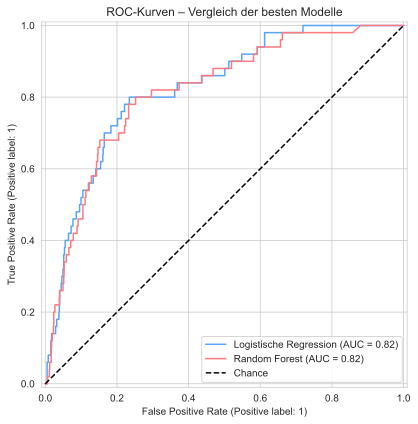

In [29]:
## ROC-Kurven-Vergleich

fig, ax = plt.subplots(figsize=(7, 6))

RocCurveDisplay.from_predictions(
    y_test,
    proba_test_lg,
    name="Logistische Regression",
    ax=ax,
    curve_kwargs={"color": PALETTE[0]},
)

RocCurveDisplay.from_predictions(
    y_test,
    proba_test_rf,
    name="Random Forest",
    ax=ax,
    curve_kwargs={"color": PALETTE[1]},
)

# Chance-Linie 
ax.plot([0, 1], [0, 1], linestyle="--", color="black", label="Chance")

ax.set_title("ROC-Kurven – Vergleich der besten Modelle")
ax.legend()
plt.tight_layout()
plt.show()

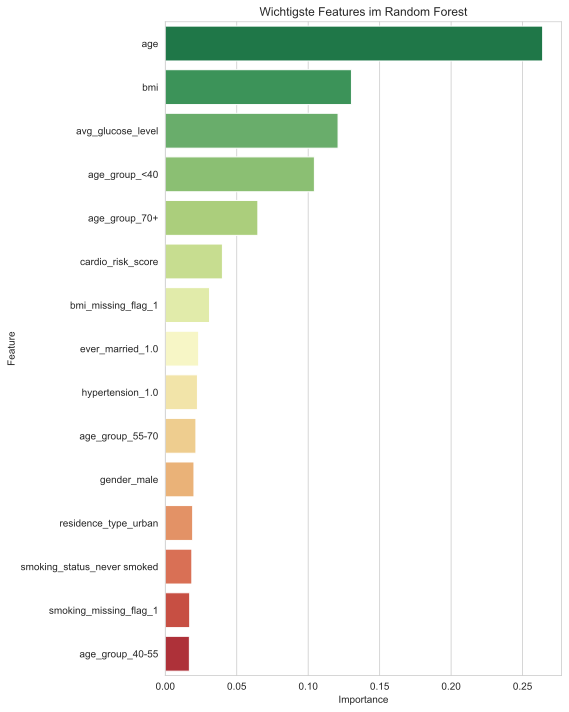

In [30]:
## Feature Importances

ohe = best_logreg.named_steps["preprocess"].named_transformers_["cat"]["onehot"]
cat_feature_names = ohe.get_feature_names_out(categorical_features)

all_feature_names = np.concatenate([
    numeric_features,
    cat_feature_names,
])

rf_model = best_rf.named_steps["model"]
importances = rf_model.feature_importances_

fi_df = pd.DataFrame({
    "Feature": all_feature_names,
    "Importance": importances,
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(8, 10))
sns.barplot(
    data=fi_df.head(15),
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="RdYlGn_r",
    legend=False
)
plt.title("Wichtigste Features im Random Forest")
plt.tight_layout()
plt.show()

### **Feststellungen**

- Beide Modelle logistische Regression und Random Forest erreichen in der Cross-Validation und auf dem Testset eine ROC-AUC von circa 0.82.  
Damit können sie das Schlaganfallrisiko deutlich besser als Zufall von „kein Schlaganfall“ unterscheiden.

- Die ROC-Kurven der beiden Modelle liegen sehr nahe beieinander. Es gibt keinen klaren Gewinner, was darauf hindeutet, dass die relevanten Zusammenhänge  
im Datensatz weitgehend durch ein einfacheres, eher lineares Modell(logistische Regression) erfasst werden können.

- Das starke Klassenungleichgewicht (nur ca. 5 % Schlaganfall-Fälle) prägt die Ergebnisse deutlich:
  - Beide Modelle erreichen einen hohen Recall für die Minderheitsklasse (≈ 0.8), erkennen also einen grossen Teil der Schlaganfall-Fälle.
  - Gleichzeitig ist die Precision der Klasse 1 niedrig (≈ 0.12–0.14), was auf viele False Positives hinweist.  
  → Typisch für ein Screening-Szenario, in dem „lieber ein Fehlalarm mehr als ein verpasster Fall“ gilt.

- Die Wahl von PR-AUC (Average Precision) als Hauptmetrik und `refit="avg_prec"` im Hyperparameter-Tuning erweist sich als sinnvoll:  
  Die Modelle werden so explizit darauf optimiert, bei unausgeglichenen Daten eine gute Trennung der seltenen Klasse zu liefern.

- Durch das Threshold-Tuning auf dem Validationsset (Recall-Ziel ≥ 0.90) kann das Modellverhalten gezielt an einen medizinischen Anwendungsfall angepasst werden:
  - Der Standard-Schwellenwert von 0.5 wäre ungeeignet und würde zu viele Schlaganfall-Fälle übersehen.
  - Ein angepasster, niedrigerer Threshold erhöht den Recall deutlich, akzeptiert dafür bewusst zusätzliche False Positives.

- Der Vergleich zwischen GridSearchCV (LogReg) und RandomizedSearchCV (Random Forest) zeigt,
  dass RandomizedSearch eine effiziente Alternative darstellt:  
  Der Suchraum kann breit gehalten werden, ohne dass die Rechenzeit explodiert, und die Modellgüte bleibt im gleichen Bereich.


---
## **Diskussion und Fazit**

### 1. Interpretation der Ergebnisse

**Welches Modell funktioniert am besten?**  
- Logistische Regression und Random Forest erreichen beide eine ROC-AUC von ca. 0.82–0.84.  
- Die ROC-Kurven liegen fast übereinander → kein klarer Gewinner.  
- Der Random Forest erzielt leicht höhere PR-AUC-Werte, die Unterschiede sind aber gering.  
- Aufgrund der besseren Interpretierbarkeit ist die logistische Regression in einem medizinischen Kontext besonders attraktiv.

**Wie gut lösen die Modelle das formulierte Problem?**  
- Ziel: Risikopersonen erkennen, nicht perfekte Vorhersage.  
- Beide Modelle erreichen:
  - Recall Klasse 1 ≈ 0.80 → grosser Teil der Schlaganfallfälle wird erkannt.  
  - Precision Klasse 1 ≈ 0.12–0.14 → viele Fehlalarme, aber akzeptabel für ein Screening.  
- Damit eignen sich die Modelle als Frühwarnsystem, nicht als alleinige Entscheidungsbasis.

**Entsprechen die Ergebnisse euren Erwartungen?**  
- Ja, weitgehend:
  - Erwartet wurde, dass Alter, Glukoselevel und kardiovaskuläre Vorerkrankungen starke Prädiktoren sind → das bestätigt sich.  
  - Ebenfalls erwartet: Imbalance führt zu niedriger Precision bei trotzdem hohem Recall.  
- Überraschend war, dass der Random Forest nicht deutlich besser als die logistische Regression ist → spricht für eher einfache, quasi-lineare Zusammenhänge im Datensatz.


### 2. Verbesserungsvorschläge für die Datenmodelle

**Umgang mit Imbalance verbessern**  
- Einsatz von Resampling-Methoden:
  - z. B. SMOTE, Random Oversampling oder Undersampling.  
- Test von Imbalance-sensitiven Algorithmen:
  - Balanced Random Forest, Gradient Boosting.

**Feature-Qualität und Modellkomplexität erhöhen**  
- Erweiterung des Feature-Sets, z. B.:
  - detailliertere klinische Variablen (Laborwerte, Medikation, zeitliche Verläufe).  

### 3. Lernerfahrungen und wichtigste Erkenntnisse

**Technische Lernpunkte**  
- Bedeutung einer sauberen Präprozessierung:
  - Konsistente Datentypen, saubere Kategorien, sinnvolles Feature Engineering.  
- Praktischer Umgang mit:
  - Pipelines und ColumnTransformer (Vermeidung von Data Leakage).  
  - Stratifizierter Cross-Validation und Hyperparameter-Tuning (GridSearchCV / RandomizedSearchCV).  
  - Mehreren Metriken (ROC-AUC, PR-AUC, Recall, F2 etc.) statt nur Accuracy.

**Inhaltliche und konzeptionelle Erkenntnisse**  
- **Imbalance ändert alles**:
  - Accuracy ist praktisch wertlos → PR-AUC, Recall und F-Scores werden zentral.  
- **Modellierung ist immer an den Kontext gebunden**:
  - In der Medizin zählt oft: „lieber ein Fehlalarm mehr als ein verpasster Fall“.

### 4. Gesamtfazit

- Die Projektarbeit zeigt, dass sich das Schlaganfallrisiko mit einfachen Gesundheits- und Lebensstilvariablen  vorhersagen lässt.  
- Beide Modelle eignen sich als Unterstützungstools, um Risikopatient:innen frühzeitig zu identifizieren – insbesondere im Sinne eines Screenings mit hohem Recall.  
- Gleichzeitig wird deutlich, dass solche Modelle:
  - nicht perfekt sind,
  - durch Imbalance viele Fehlalarme erzeugen.

Insgesamt hat das Projekt ein praxisnahes Verständnis für den kompletten Machine-Learning-Prozess vermittelt, von der Datenbereinigung über Feature Engineering, Modellierung und 
Tuning bis hin zur kritischen Interpretation der Ergebnisse im medizinischen Kontext.


---
## **Literaturverweis** 

Juchler, N. (2025). SW07 – Decision Trees (Lösungsskript) [Unterrichtsmaterial, Kurs „Maschinelles Lernen (MaLe-AD24-HS25)”]. Zürcher Hochschule für Angewandte Wissenschaften (ZHAW).

Juchler, N. (2025). SW08 – Ensemble Learning (Tutorial) [Übungsblatt, Kurs „Maschinelles Lernen (MaLe-AD24-HS25)”]. Zürcher Hochschule für Angewandte Wissenschaften (ZHAW).

Juchler, N. (2025). SW08 – Random Forests (Lösungsskript) [Unterrichtsmaterial, Kurs „Maschinelles Lernen (MaLe-AD24-HS25)”]. Zürcher Hochschule für Angewandte Wissenschaften (ZHAW).

Juchler, N. (2025). SW08 – k-Nearest Neighbors (Lösungsskript) [Unterrichtsmaterial, Kurs „Maschinelles Lernen (MaLe-AD24-HS25)”]. Zürcher Hochschule für Angewandte Wissenschaften (ZHAW).

Juchler, N. (2025). SW09 – Clustering (Lösungsskript) [Unterrichtsmaterial, Kurs „Maschinelles Lernen (MaLe-AD24-HS25)”]. Zürcher Hochschule für Angewandte Wissenschaften (ZHAW).

Juchler, N. (2025). SW10 – Dimensionality Reduction (Lösungsskript) [Unterrichtsmaterial, Kurs „Maschinelles Lernen (MaLe-AD24-HS25)”]. Zürcher Hochschule für Angewandte Wissenschaften (ZHAW).

Juchler, N. (2025). SW10 – LDA Detailed (Tutorial) [Übungsblatt, Kurs „Maschinelles Lernen (MaLe-AD24-HS25)”]. Zürcher Hochschule für Angewandte Wissenschaften (ZHAW).

Juchler, N. (2025). SW11 – Hyperparameter Tuning (Tutorial) [Übungsblatt, Kurs „Maschinelles Lernen (MaLe-AD24-HS25)”]. Zürcher Hochschule für Angewandte Wissenschaften (ZHAW).

Juchler, N. (2025). SW11 – Support Vector Machines (Tutorial) [Übungsblatt, Kurs „Maschinelles Lernen (MaLe-AD24-HS25)”]. Zürcher Hochschule für Angewandte Wissenschaften (ZHAW).


OpenAI. (2025). ChatGPT (Version GPT-5.1 Thinking) [Large Language Model]. OpenAI. https://chat.openai.com/
* Zur sprachlichen und inhaltlichen Unterstützung wurde das KI-Sprachmodell ChatGPT (OpenAI, 2025) eingesetzt.  
Das Modell diente insbesondere zur Formulierungsvorschlägen, zum Überprüfen von Code-Snippets sowie zum Erklären statistischer Methoden (z. B. PCA, LDA, Hyperparameter-Tuning).  
Alle Ergebnisse wurden kritisch geprüft, angepasst und inhaltlich eigenständig verantwortet


SorianO, F. (2020). Stroke Prediction Dataset [Datensatz]. Kaggle. https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., u. a. (2011). Scikit-learn: Machine learning in Python. Journal of Machine Learning Research, 12, 2825–2830.

Hunter, J. D. (2007). Matplotlib: A 2D graphics environment. Computing in Science & Engineering, 9(3), 90–95.

Waskom, M. L. (2021). Seaborn: Statistical data visualization. Journal of Open Source Software, 6(60), 3021.
